Project name
overview
the dataset


## Import the neccary libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import glob
import os

import warnings
warnings.filterwarnings('ignore')

In [2]:
# For cleaner plots
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

In [3]:
files = [file for file in os.listdir('../data/raw/')]
data = pd.DataFrame()
for file in files:
    all_csvs = pd.read_csv('../data/raw/' + file)
    data = pd.concat([all_csvs, data])   
data.to_csv('../data/processed/uk_pay_gap_2017-25_.csv', index=False)

## Read the dataset

In [4]:
df = pd.read_csv('../data/processed/uk_pay_gap_2017-25_.csv')

In [5]:
df.head()

,EmployerName,EmployerId,Address,PostCode,CompanyNumber,SicCodes,DiffMeanHourlyPercent,DiffMedianHourlyPercent,DiffMeanBonusPercent,DiffMedianBonusPercent,MaleBonusPercent,FemaleBonusPercent,MaleLowerQuartile,FemaleLowerQuartile,MaleLowerMiddleQuartile,FemaleLowerMiddleQuartile,MaleUpperMiddleQuartile,FemaleUpperMiddleQuartile,MaleTopQuartile,FemaleTopQuartile,CompanyLinkToGPGInfo,ResponsiblePerson,EmployerSize,CurrentName,SubmittedAfterTheDeadline,DueDate,DateSubmitted
0,1ST HOME CARE LTD.,17484,"Suite 1, Ground Floor Academy House, 1346 Shet...",G32 9AT,SC272838,"86900,\n88100",-0.72,0.06,NaN,NaN,0.0,0.0,14.71,85.29,5.89,94.11,11.77,88.23,14.71,85.29,NaN,David Sargent (CEO),Less than 250,1ST HOME CARE LTD.,False,2025/04/05 00:00:00,2024/07/01 15:43:41
1,6 POINT 6 LIMITED,22664,"30 Fenchurch Street, London, England, EC3M 3BD",EC3M 3BD,07946687,62020,22.00,24.00,15.00,33.0,92.0,87.0,58.00,42.00,69.00,31.00,82.00,18.00,89.00,11.00,NaN,Janet Coulthurst (Chief of Staff),250 to 499,6 POINT 6 LIMITED,False,2025/04/05 00:00:00,2024/12/16 11:12:30
2,725 LIMITED,17859,"48 High Street, Gravesend, Kent, England, DA11...",DA11 0AY,05983359,"41100,\n78200",2.50,3.78,NaN,NaN,0.0,0.0,31.00,69.00,31.00,69.00,31.00,69.00,51.00,49.00,NaN,DIPESH LIMBU (ACCOUNTANT),250 to 499,725 LIMITED,False,2025/04/05 00:00:00,2024/12/16 15:06:04
3,A J RAYSON LIMITED,23378,"Bartle House, Oxford Court, Manchester, Englan...",M2 3WQ,14187704,70229,1.37,5.24,NaN,NaN,0.0,0.0,9.00,91.00,21.00,79.00,22.00,78.00,35.80,64.20,NaN,Abigail Rayson (Director),250 to 499,A J RAYSON LIMITED,False,2025/04/05 00:00:00,2024/05/20 10:03:35
4,A P P WHOLESALE LIMITED,21477,"Unit 1 Radford Industrial Estate, Goodhall Str...",NW10 6UA,06552800,46740,-4.26,15.13,-33.39,-20.0,88.0,95.0,91.94,8.06,86.89,13.11,76.67,23.33,84.17,15.83,https://www.lordsgrouptradingplc.co.uk/about-u...,Anne Prince (Group HR Director),Less than 250,A P P WHOLESALE LIMITED,False,2025/04/05 00:00:00,2024/09/17 13:59:33


## Data Exploration

In [6]:
df.shape

(72810, 27)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72810 entries, 0 to 72809
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   EmployerName               72810 non-null  object 
 1   EmployerId                 72810 non-null  int64  
 2   Address                    72714 non-null  object 
 3   PostCode                   72522 non-null  object 
 4   CompanyNumber              63108 non-null  object 
 5   SicCodes                   68080 non-null  object 
 6   DiffMeanHourlyPercent      72810 non-null  float64
 7   DiffMedianHourlyPercent    72810 non-null  float64
 8   DiffMeanBonusPercent       58000 non-null  float64
 9   DiffMedianBonusPercent     57998 non-null  float64
 10  MaleBonusPercent           72810 non-null  float64
 11  FemaleBonusPercent         72810 non-null  float64
 12  MaleLowerQuartile          72411 non-null  float64
 13  FemaleLowerQuartile        72411 non-null  flo

- Noticed missing values

In [8]:
df.isnull().sum()

EmployerName                     0
EmployerId                       0
Address                         96
PostCode                       288
CompanyNumber                 9702
SicCodes                      4730
DiffMeanHourlyPercent            0
DiffMedianHourlyPercent          0
DiffMeanBonusPercent         14810
DiffMedianBonusPercent       14812
MaleBonusPercent                 0
FemaleBonusPercent               0
MaleLowerQuartile              399
FemaleLowerQuartile            399
MaleLowerMiddleQuartile        399
FemaleLowerMiddleQuartile      399
MaleUpperMiddleQuartile        399
FemaleUpperMiddleQuartile      399
MaleTopQuartile                399
FemaleTopQuartile              399
CompanyLinkToGPGInfo         25860
ResponsiblePerson            12659
EmployerSize                     0
CurrentName                      0
SubmittedAfterTheDeadline        0
DueDate                          0
DateSubmitted                    0
dtype: int64

In [9]:
# Missing value count and percentage
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['Column', 'MissingValues']
missing_df['MissingPercentage'] = 100 * missing_df['MissingValues'] / len(df)
missing_df = missing_df.sort_values(by='MissingPercentage', ascending=False)

# Display missing value summary
missing_df

,Column,MissingValues,MissingPercentage
20,CompanyLinkToGPGInfo,25860,35.517099
9,DiffMedianBonusPercent,14812,20.343359
8,DiffMeanBonusPercent,14810,20.340613
21,ResponsiblePerson,12659,17.386348
4,CompanyNumber,9702,13.325093
5,SicCodes,4730,6.496360
14,MaleLowerMiddleQuartile,399,0.548002
13,FemaleLowerQuartile,399,0.548002
12,MaleLowerQuartile,399,0.548002
16,MaleUpperMiddleQuartile,399,0.548002


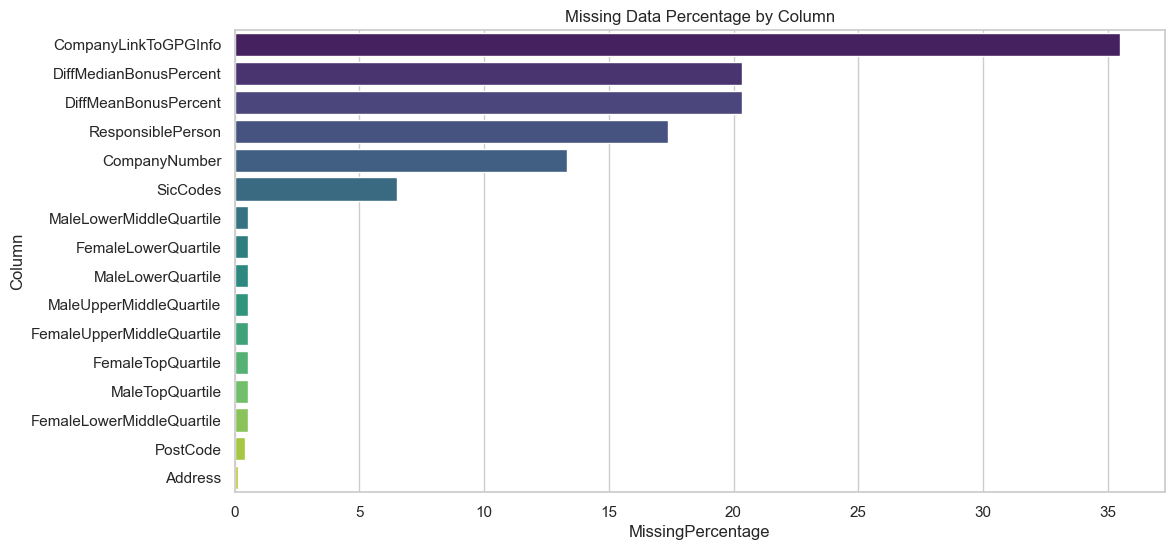

In [10]:
# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df[missing_df.MissingPercentage > 0], 
            x='MissingPercentage', 
            y='Column', 
            palette='viridis')
plt.title('Missing Data Percentage by Column')
plt.show()

In [11]:
df[df['CompanyLinkToGPGInfo'].isna()].head(3)

,EmployerName,EmployerId,Address,PostCode,CompanyNumber,SicCodes,DiffMeanHourlyPercent,DiffMedianHourlyPercent,DiffMeanBonusPercent,DiffMedianBonusPercent,MaleBonusPercent,FemaleBonusPercent,MaleLowerQuartile,FemaleLowerQuartile,MaleLowerMiddleQuartile,FemaleLowerMiddleQuartile,MaleUpperMiddleQuartile,FemaleUpperMiddleQuartile,MaleTopQuartile,FemaleTopQuartile,CompanyLinkToGPGInfo,ResponsiblePerson,EmployerSize,CurrentName,SubmittedAfterTheDeadline,DueDate,DateSubmitted
0,1ST HOME CARE LTD.,17484,"Suite 1, Ground Floor Academy House, 1346 Shet...",G32 9AT,SC272838,"86900,\n88100",-0.72,0.06,NaN,NaN,0.0,0.0,14.71,85.29,5.89,94.11,11.77,88.23,14.71,85.29,NaN,David Sargent (CEO),Less than 250,1ST HOME CARE LTD.,False,2025/04/05 00:00:00,2024/07/01 15:43:41
1,6 POINT 6 LIMITED,22664,"30 Fenchurch Street, London, England, EC3M 3BD",EC3M 3BD,07946687,62020,22.00,24.00,15.0,33.0,92.0,87.0,58.00,42.00,69.00,31.00,82.00,18.00,89.00,11.00,NaN,Janet Coulthurst (Chief of Staff),250 to 499,6 POINT 6 LIMITED,False,2025/04/05 00:00:00,2024/12/16 11:12:30
2,725 LIMITED,17859,"48 High Street, Gravesend, Kent, England, DA11...",DA11 0AY,05983359,"41100,\n78200",2.50,3.78,NaN,NaN,0.0,0.0,31.00,69.00,31.00,69.00,31.00,69.00,51.00,49.00,NaN,DIPESH LIMBU (ACCOUNTANT),250 to 499,725 LIMITED,False,2025/04/05 00:00:00,2024/12/16 15:06:04


In [12]:
df['CompanyLinkToGPGInfo'].fillna('unknown', inplace=True)

In [13]:
# fill na in this column with 'unknown'
df[df['CompanyLinkToGPGInfo'].isna()].head(3)

,EmployerName,EmployerId,Address,PostCode,CompanyNumber,SicCodes,DiffMeanHourlyPercent,DiffMedianHourlyPercent,DiffMeanBonusPercent,DiffMedianBonusPercent,MaleBonusPercent,FemaleBonusPercent,MaleLowerQuartile,FemaleLowerQuartile,MaleLowerMiddleQuartile,FemaleLowerMiddleQuartile,MaleUpperMiddleQuartile,FemaleUpperMiddleQuartile,MaleTopQuartile,FemaleTopQuartile,CompanyLinkToGPGInfo,ResponsiblePerson,EmployerSize,CurrentName,SubmittedAfterTheDeadline,DueDate,DateSubmitted


## Univarte Analysis

### Numercal Columns

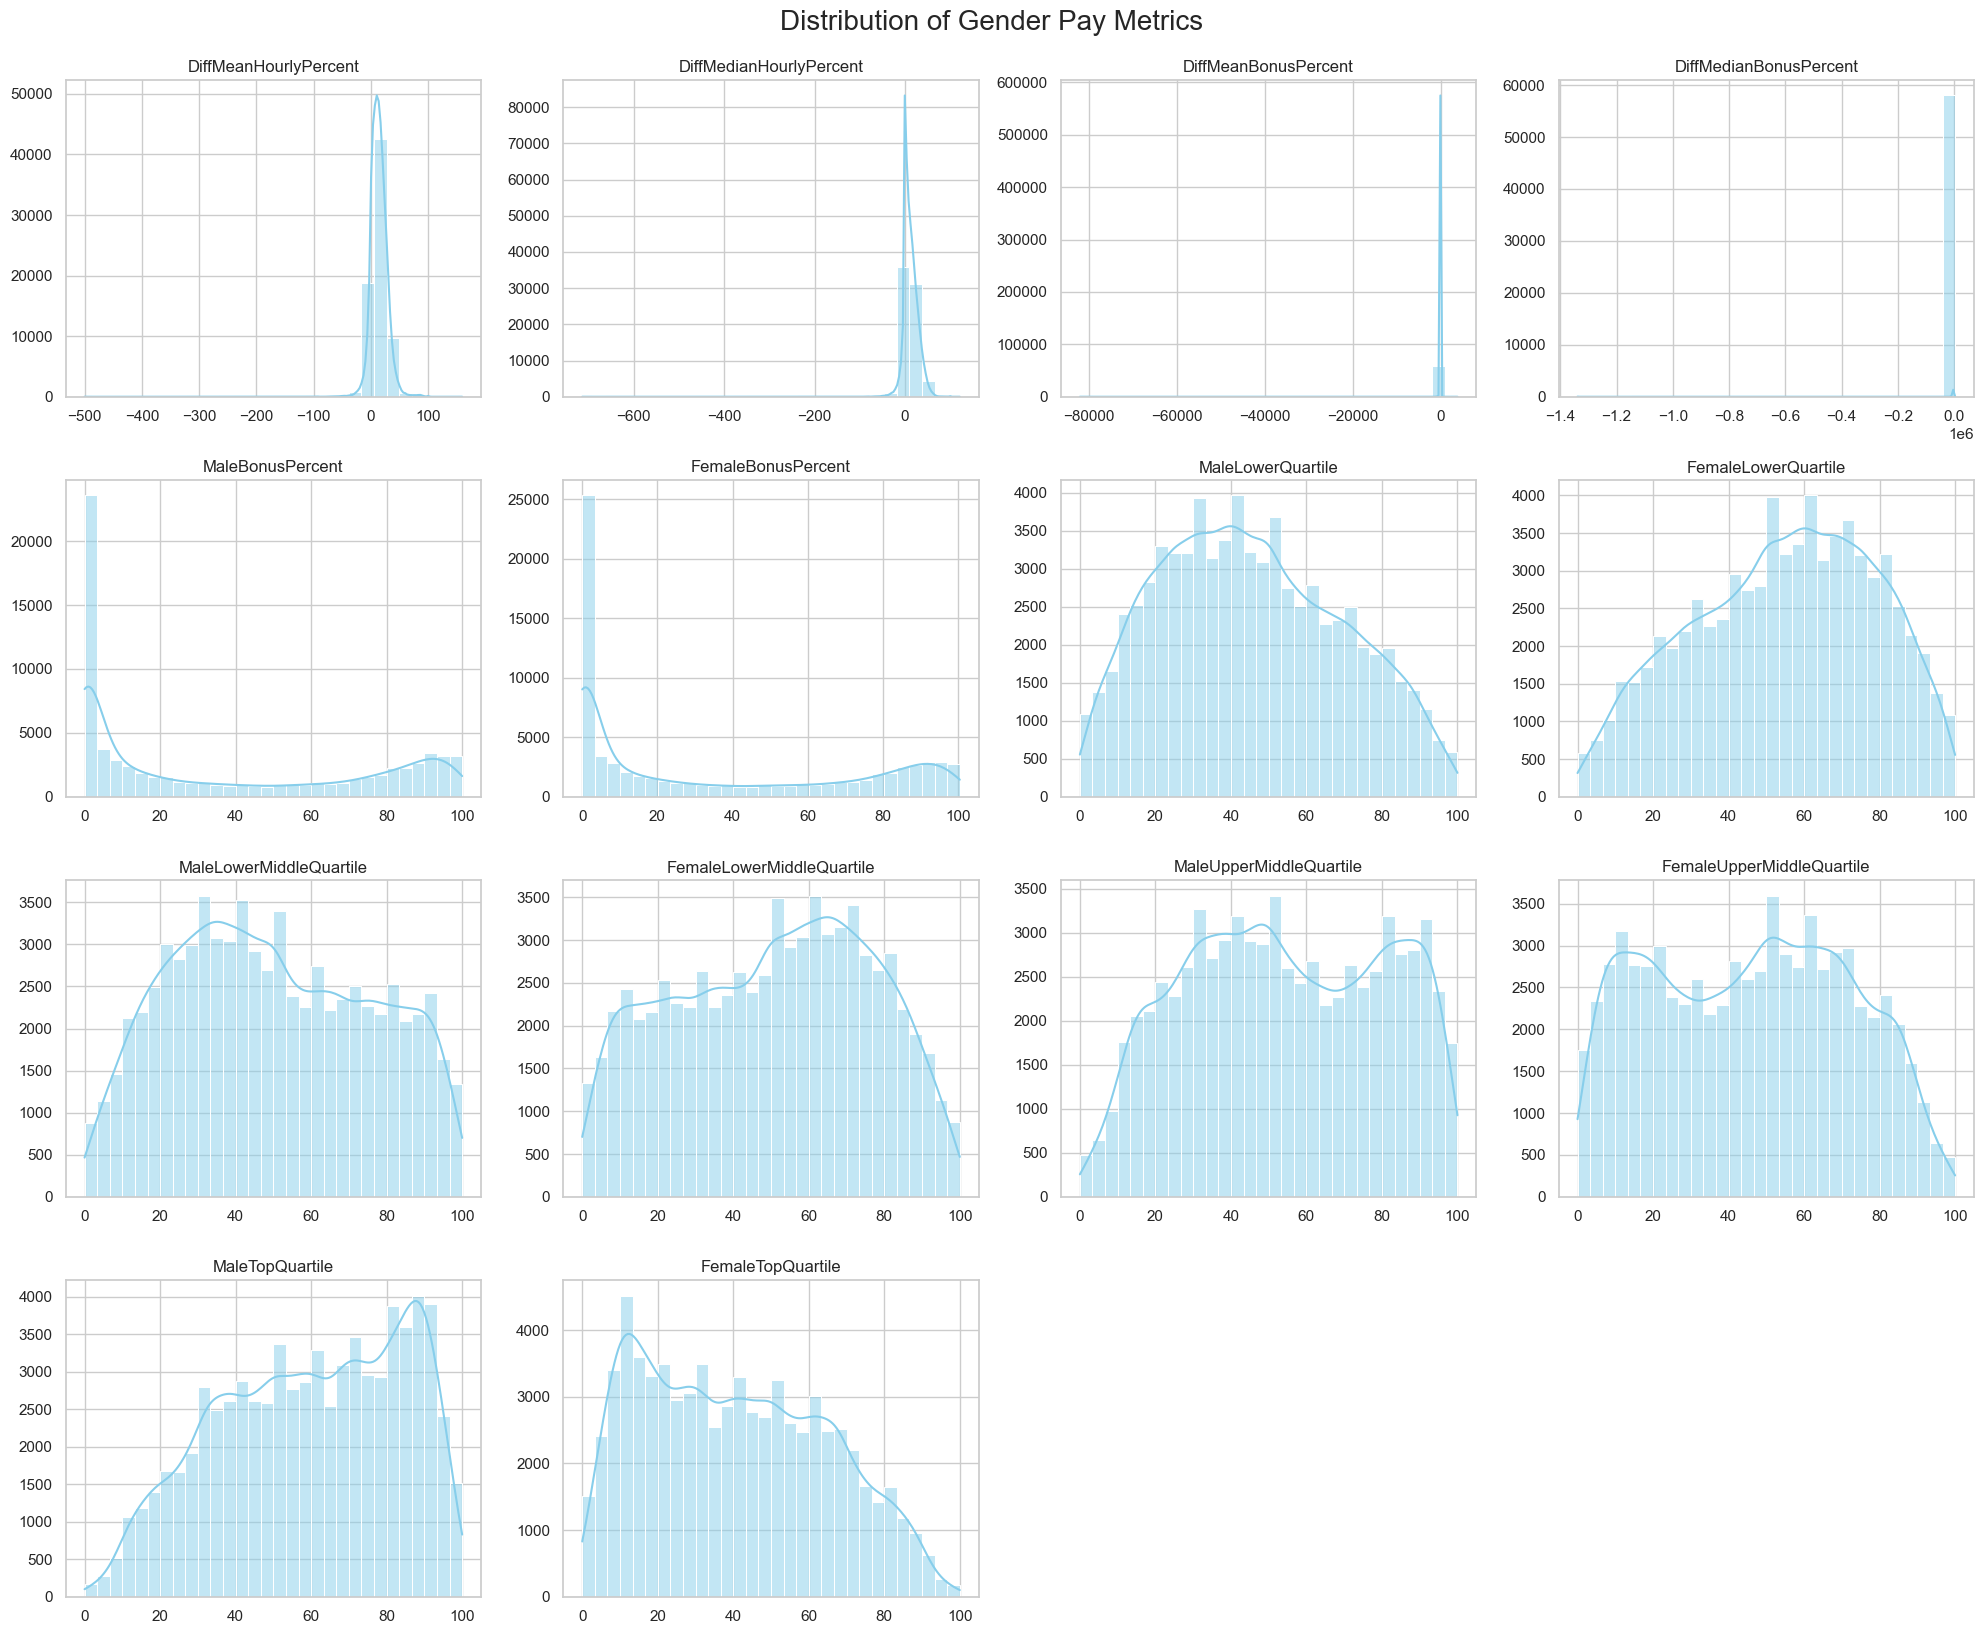

In [15]:
# List of the gender pay-related columns
columns_to_plot = [
    'DiffMeanHourlyPercent', 'DiffMedianHourlyPercent',
    'DiffMeanBonusPercent', 'DiffMedianBonusPercent',
    'MaleBonusPercent', 'FemaleBonusPercent',
    'MaleLowerQuartile', 'FemaleLowerQuartile',
    'MaleLowerMiddleQuartile', 'FemaleLowerMiddleQuartile',
    'MaleUpperMiddleQuartile', 'FemaleUpperMiddleQuartile',
    'MaleTopQuartile', 'FemaleTopQuartile'
]

# Set up subplots: 4 rows x 4 columns
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

# Plot each column
for i, col in enumerate(columns_to_plot):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30, color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide any extra subplots (if less than 16 total)
for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Distribution of Gender Pay Metrics", fontsize=20, y=1.02)
plt.show()

## Biavariate Analysis

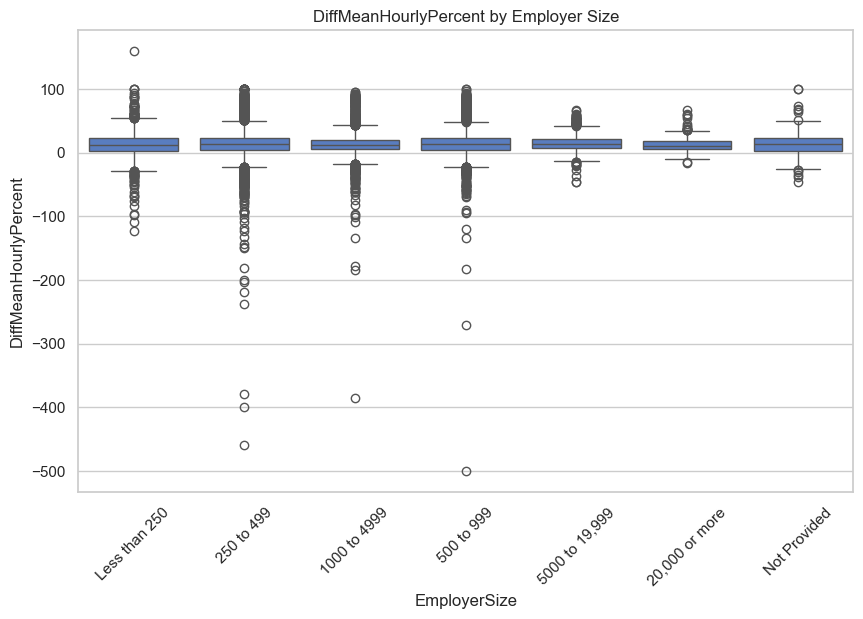

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='EmployerSize', y='DiffMeanHourlyPercent', data=df)
plt.title('DiffMeanHourlyPercent by Employer Size')
plt.xticks(rotation=45)
plt.show()

In [ ]:
sns.scatterplot(data=df, x='DiffMeanHourlyPercent', y='DiffMedianHourlyPercent')
plt.title('Diff Mean vs Median Hourly Percent')
plt.show()

## Multivariate Analysis

In [ ]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".1f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
sample_df = df.sample(1000, random_state=42)  # speed it up
sns.pairplot(sample_df[['DiffMeanHourlyPercent', 'DiffMedianHourlyPercent', 
                        'MaleBonusPercent', 'FemaleBonusPercent']])
plt.show()

## Data Cleaning

# Outlier Detection

In [ ]:
# Example using IQR method for multiple columns
for col in ['col1', 'col2']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

In [ ]:
# 1. Box plots before outlier removal
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(ax=axes[0, 0], x=df['col1'])
sns.boxplot(ax=axes[0, 1], x=df['col2'])
sns.boxplot(ax=axes[1, 0], x=df['col3'])
sns.boxplot(ax=axes[1, 1], x=df['col4'])
fig.suptitle('Boxplots Before Outlier Removal')
plt.tight_layout()

# Show before plots
plt.show()

In [ ]:
# Ensure the DataFrame has unique indices (important step)
df = df.reset_index(drop=True)

# Box plots before outlier removal
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plotting the boxplots for different columns
sns.boxplot(ax=axes[0, 0], x=df['DiffMeanHourlyPercent'])
sns.boxplot(ax=axes[0, 1], x=df['DiffMedianHourlyPercent'])
sns.boxplot(ax=axes[1, 0], x=df['DiffMeanBonusPercent'])
sns.boxplot(ax=axes[1, 1], x=df['DiffMedianBonusPercent'])

# Adding title and ensuring proper layout
fig.suptitle('Boxplots Before Outlier Removal')
plt.tight_layout()

# Show the plots
plt.show()

# Analysis

## Line Chart: Average Gender Pay Gap Over Time

In [ ]:
# Extract the year from the DateSubmitted column
df_cleaned['year'] = pd.to_datetime(df_cleaned['DateSubmitted']).dt.year

# Group by year and calculate the mean of hourly and median pay gaps
df_avg_gap_yearly = df_cleaned.groupby('year')[['DiffMeanHourlyPercent', 'DiffMedianHourlyPercent']].mean().reset_index()

# Plot the line chart to show the trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_avg_gap_yearly, x='year', y='DiffMeanHourlyPercent', label='Mean Hourly Pay Gap', color='blue')
sns.lineplot(data=df_avg_gap_yearly, x='year', y='DiffMedianHourlyPercent', label='Median Hourly Pay Gap', color='red')

plt.title('Average Gender Pay Gap Over Time')
plt.xlabel('Year')
plt.ylabel('Pay Gap (%)')
plt.legend(title='Pay Gap Type')
plt.xticks(rotation=45)
plt.show()


## Side-by-Side Comparisons for Hourly vs. Bonus Gaps

In [ ]:
# Group by year and calculate the mean of hourly and bonus pay gaps
df_avg_gap_yearly_bonus = df_cleaned.groupby('year')[['DiffMeanHourlyPercent', 'DiffMeanBonusPercent']].mean().reset_index()

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot the first chart for Hourly Pay Gap
sns.lineplot(data=df_avg_gap_yearly_bonus, x='year', y='DiffMeanHourlyPercent', ax=ax[0], color='blue')
ax[0].set_title('Average Hourly Pay Gap Over Time')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Hourly Pay Gap (%)')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

# Plot the second chart for Bonus Pay Gap
sns.lineplot(data=df_avg_gap_yearly_bonus, x='year', y='DiffMeanBonusPercent', ax=ax[1], color='green')
ax[1].set_title('Average Bonus Pay Gap Over Time')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Bonus Pay Gap (%)')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Bar Chart: Employer Size vs DiffMeanHourlyPercent (Aggregated Mean)

In [ ]:
# Group by EmployerSize and calculate the mean DiffMeanHourlyPercent for each size category
df_avg_gap_size = df_cleaned.groupby('EmployerSize')['DiffMeanHourlyPercent'].mean().reset_index()

# Plot the bar chart to visualize the average hourly pay gap by employer size
plt.figure(figsize=(10, 6))
sns.barplot(data=df_avg_gap_size, x='EmployerSize', y='DiffMeanHourlyPercent', palette='Blues_d')
plt.title('Average Gender Pay Gap by Employer Size')
plt.xlabel('Employer Size')
plt.ylabel('Average Hourly Pay Gap (%)')
plt.xticks(rotation=45)
plt.show()


## Boxplots by Employer Size

In [ ]:
# Plotting the boxplot to show the distribution of pay gaps by employer size
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned, x='EmployerSize', y='DiffMeanHourlyPercent', palette='coolwarm')
plt.title('Distribution of Gender Pay Gaps by Employer Size')
plt.xlabel('Employer Size')
plt.ylabel('Gender Pay Gap (%)')
plt.xticks(rotation=45)
plt.show()

## Horizontal Bar Chart: Top 10 SIC Code Groups by Mean Pay Gap

In [ ]:
# Create a lookup table (replace this with a complete reference table)
sic_code_reference = {
    100: 'Agriculture', 200: 'Manufacturing', 300: 'Retail', 400: 'Finance', 
    500: 'Tech', 600: 'Healthcare', 700: 'Education', 800: 'Construction', 
    900: 'Transport', 1000: 'Wholesale'  # Add more codes here
}

# Group by SicCodes and calculate the mean DiffMeanHourlyPercent for each industry
df_avg_gap_industry = df_cleaned.groupby('SicCodes')['DiffMeanHourlyPercent'].mean().reset_index()

# Map SicCodes to industry names
df_avg_gap_industry['Industry'] = df_avg_gap_industry['SicCodes'].map(sic_code_reference)

# Sort by the mean pay gap in descending order and get the top 10 industries
df_avg_gap_industry_sorted = df_avg_gap_industry.sort_values(by='DiffMeanHourlyPercent', ascending=False).head(10)

# Plot the horizontal bar chart for top 10 industries with highest pay gaps
plt.figure(figsize=(10, 6))
sns.barplot(data=df_avg_gap_industry_sorted, x='DiffMeanHourlyPercent', y='Industry', palette='viridis')
plt.title('Top 10 Industries by Mean Gender Pay Gap')
plt.xlabel('Average Gender Pay Gap (%)')
plt.ylabel('Industry')
plt.show()


## Visualize the Gender Pay Gap by Sector

In [ ]:
def map_sic_to_sector(sic):
    """
    Map a SIC code (as a string) to a broad sector.
    We use the first two digits (converted to an integer)
    and assign a sector by common UK SIC 2007 ranges.
    """
    if not sic or sic.strip() == "":
        return 'Unknown'
    sic = sic.strip()
    try:
        prefix = int(sic[:2])
    except Exception as e:
        return 'Unknown'
    if 1 <= prefix <= 3:
        return 'Agriculture, Forestry & Fishing'
    elif 5 <= prefix <= 9:
        return 'Mining & Quarrying'
    elif 10 <= prefix <= 33:
        return 'Manufacturing'
    elif prefix == 35:
        return 'Utilities'
    elif 36 <= prefix <= 39:
        return 'Water & Waste Management'
    elif 41 <= prefix <= 43:
        return 'Construction'
    elif 45 <= prefix <= 47:
        return 'Wholesale & Retail Trade'
    elif 49 <= prefix <= 53:
        return 'Transportation & Storage'
    elif prefix == 55:
        return 'Accommodation & Food Services'
    elif 58 <= prefix <= 63:
        return 'Information & Communication'
    elif 64 <= prefix <= 66:
        return 'Financial & Insurance'
    elif prefix == 68:
        return 'Real Estate'
    elif 69 <= prefix <= 75:
        return 'Professional, Scientific & Technical Activities'
    elif 77 <= prefix <= 82:
        return 'Administrative & Support Services'
    elif prefix == 84:
        return 'Public Administration & Defence'
    elif prefix == 85:
        return 'Education'
    elif 86 <= prefix <= 88:
        return 'Human Health & Social Work'
    elif prefix == 90:
        return 'Arts, Entertainment & Recreation'
    elif 91 <= prefix <= 93:
        return 'Other Service Activities'
    elif prefix == 94:
        return 'Households as Employers'
    elif prefix == 95:
        return 'Extraterritorial Organizations'
    else:
        return 'Other'

In [ ]:
# Create a new column 'Sector' based on the first SIC code
def extract_sector(sic_codes):
    # Split by newline or comma; strip whitespace
    codes = [code.strip() for code in sic_codes.replace(',', '\n').split('\n') if code.strip()]
    if codes:
        return map_sic_to_sector(codes[0])
    return 'Unknown'

df_cleaned['Sector'] = df_cleaned['SicCodes'].apply(extract_sector)

In [ ]:
# Group by Sector and calculate the mean gender pay gap
sector_gap = df_cleaned.groupby('Sector')['DiffMeanHourlyPercent'].mean().reset_index()
sector_gap = sector_gap.sort_values(by='DiffMeanHourlyPercent', ascending=False)

# Plot a bar chart: Sector vs. Average Gender Pay Gap
plt.figure(figsize=(12, 7))
sns.barplot(data=sector_gap, x='DiffMeanHourlyPercent', y='Sector', palette='viridis')
plt.title('Average Gender Pay Gap Across Sectors')
plt.xlabel('Average Hourly Gender Pay Gap (%)')
plt.ylabel('Sector')
plt.show()


## Average Gender Pay Gap by Region

In [ ]:
def extract_region(postcode):
    """
    Simple function to return a region name based on postcode prefixes.
    Adjust rules for more accurate mapping.
    """
    if not postcode or pd.isnull(postcode):
        return "Unknown"
    pc = postcode.strip().upper()
    # Common London postcode prefixes
    if pc.startswith(("EC", "WC", "E1", "W1", "N12", "E14")):
        return "London"
    # Scottish prefixes (example)
    if pc.startswith(("EH", "G", "AB", "FK", "DD")):
        return "Scotland"
    # Welsh prefixes
    if pc.startswith(("CF", "NP", "SA")):
        return "Wales"
    # Northern Ireland
    if pc.startswith("BT"):
        return "Northern Ireland"
    # For demonstration, fall back to a default region
    return "Other"

# Extract all unique postcodes from the 'PostCode' column
unique_postcodes = df_cleaned['PostCode'].unique()

# Create a dictionary mapping each unique postcode to its region
postcode_region_mapping = {pc: extract_region(pc) for pc in unique_postcodes}

# Apply this mapping to create a new column 'Region' in the DataFrame
df_cleaned['Region'] = df_cleaned['PostCode'].map(postcode_region_mapping)

# Verify the results by checking the first few rows
print(df_cleaned[['PostCode', 'Region']].head())

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=region_stats.sort_values("DiffMeanHourlyPercent", ascending=False),
            x="DiffMeanHourlyPercent", y="Region", palette="coolwarm")
plt.xlabel("Average Hourly Gender Pay Gap (%)")
plt.ylabel("Region")
plt.title("Average Gender Pay Gap by Region")
plt.show()

## Stacked Bar Chart: Female vs Male Top Quartile per Year

In [ ]:
# Group by year and sum the FemaleTopQuartile and MaleTopQuartile for each year
df_top_quartile = df_cleaned.groupby('year')[['FemaleTopQuartile', 'MaleTopQuartile']].sum().reset_index()

# Plot the stacked bar chart to compare Female and Male representation in the Top Quartile
plt.figure(figsize=(12, 6))
df_top_quartile.set_index('year')[['FemaleTopQuartile', 'MaleTopQuartile']].plot(kind='bar', stacked=True, color=['pink', 'blue'], figsize=(12, 6))

plt.title('Gender Representation in the Top Quartile by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.show()

## Quartile Difference Over Time (Line or Area Chart)

In [ ]:
# Calculate the difference between FemaleTopQuartile and FemaleLowerQuartile for each year
df_cleaned['FemaleTopMinusBottomQuartile'] = df_cleaned['FemaleTopQuartile'] - df_cleaned['FemaleLowerQuartile']

# Group by year and calculate the mean of the difference for each year
df_quartile_diff = df_cleaned.groupby('year')['FemaleTopMinusBottomQuartile'].mean().reset_index()

# Plot the line chart to show the difference in female representation between top and bottom quartiles over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_quartile_diff, x='year', y='FemaleTopMinusBottomQuartile', color='purple', marker='o')

plt.title('Difference in Female Representation: Top vs. Bottom Quartile Over Time')
plt.xlabel('Year')
plt.ylabel('Difference in Female Representation')
plt.xticks(rotation=45)
plt.show()

## Boxplot: DiffMeanBonusPercent vs. DiffMeanHourlyPercent

In [ ]:
# Plot the boxplot to compare DiffMeanBonusPercent vs DiffMeanHourlyPercent
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cleaned[['DiffMeanBonusPercent', 'DiffMeanHourlyPercent']], palette='coolwarm')
plt.title('Comparison of Bonus Pay Gap vs Hourly Pay Gap')
plt.xlabel('Pay Gap Type')
plt.ylabel('Pay Gap (%)')
plt.xticks([0, 1], ['Bonus Pay Gap', 'Hourly Pay Gap'])
plt.show()

## Bar Chart: Male vs Female Bonus Percent by Year or Sector

In [ ]:
# Group by year and calculate the mean MaleBonusPercent and FemaleBonusPercent
df_bonus_by_year = df_cleaned.groupby('year')[['MaleBonusPercent', 'FemaleBonusPercent']].mean().reset_index()

# Plot the bar chart to compare Male and Female Bonus Percent by year
plt.figure(figsize=(12, 6))
df_bonus_by_year.set_index('year')[['MaleBonusPercent', 'FemaleBonusPercent']].plot(kind='bar', figsize=(12, 6))
plt.title('Male vs Female Bonus Percent by Year')
plt.xlabel('Year')
plt.ylabel('Bonus Percent (%)')
plt.xticks(rotation=45)
plt.legend(title='Gender', labels=['Male', 'Female'])
plt.show()

In [ ]:
# Group by SicCodes and calculate the mean MaleBonusPercent and FemaleBonusPercent
df_bonus_by_sector = df_cleaned.groupby('SicCodes')[['MaleBonusPercent', 'FemaleBonusPercent']].mean().reset_index()

# Map SicCodes to industry names (use your reference dictionary for SicCodes)
df_bonus_by_sector['Industry'] = df_bonus_by_sector['SicCodes'].map(sic_code_reference)

# Plot the bar chart to compare Male and Female Bonus Percent by Industry
plt.figure(figsize=(12, 6))
sns.barplot(data=df_bonus_by_sector, x='Industry', y='MaleBonusPercent', color='blue', label='Male Bonus Percent')
sns.barplot(data=df_bonus_by_sector, x='Industry', y='FemaleBonusPercent', color='pink', label='Female Bonus Percent')
plt.title('Male vs Female Bonus Percent by Industry')
plt.xlabel('Industry')
plt.ylabel('Bonus Percent (%)')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.show()

## Pie Chart: Percentage of Companies That Submit Late

In [ ]:
# Calculate the number of late and on-time submissions
submission_status = df_cleaned['SubmittedAfterTheDeadline'].value_counts()

# Plot the pie chart for late vs on-time submissions
plt.figure(figsize=(8, 8))
submission_status.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'salmon'], startangle=90, cmap='coolwarm')
plt.title('Percentage of Companies That Submit Late vs On Time')
plt.ylabel('')
plt.show()

## Boxplot or Violin Plot: DiffMeanHourlyPercent by

In [ ]:
# Plot a boxplot to compare DiffMeanHourlyPercent for companies that submitted late vs on time
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cleaned, x='SubmittedAfterTheDeadline', y='DiffMeanHourlyPercent', palette='Set2')
plt.title('Gender Pay Gap vs Submission Timeliness')
plt.xlabel('Submitted After Deadline')
plt.ylabel('Mean Hourly Pay Gap (%)')
plt.show()

In [ ]:
# Plot a violin plot to compare DiffMeanHourlyPercent for companies that submitted late vs on time
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_cleaned, x='SubmittedAfterTheDeadline', y='DiffMeanHourlyPercent', palette='Set2')
plt.title('Gender Pay Gap vs Submission Timeliness')
plt.xlabel('Submitted After Deadline')
plt.ylabel('Mean Hourly Pay Gap (%)')
plt.show()

## Regression Plot or Trend Line Projection

In [ ]:
# Prepare data for regression (e.g., DiffMeanHourlyPercent over years)
X = df_cleaned[['year']]  # Feature: year
y = df_cleaned['DiffMeanHourlyPercent']  # Target: DiffMeanHourlyPercent (gender pay gap)

# Initialize and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict the gender pay gap for the given years and future projections
years_future = np.array(range(df_cleaned['year'].min(), df_cleaned['year'].max() + 6)).reshape(-1, 1)  # Extend prediction for future 5 years
y_pred = model.predict(years_future)

# Plot the actual data and regression line
plt.figure(figsize=(12, 6))
sns.regplot(x='year', y='DiffMeanHourlyPercent', data=df_cleaned, scatter_kws={'s': 20}, line_kws={'color': 'red'}, ci=None)

# Plot the future prediction
plt.plot(years_future, y_pred, color='green', linestyle='--', label='Predicted Trend')

plt.title('Prediction of Gender Pay Gap (Hourly) Over Time')
plt.xlabel('Year')
plt.ylabel('Gender Pay Gap (%)')
plt.legend()
plt.show()